In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import pickle
import time



In [2]:
# Generate sample data for demonstration
np.random.seed(42)

# Create sample dataset
n_samples = 1000

# Features
distances = np.random.uniform(1, 50, n_samples)  # Distance in miles
order_hours = np.random.randint(0, 24, n_samples)  # Hour of day when order was placed
traffic_conditions = np.random.choice(['Light', 'Medium', 'Heavy'], n_samples, p=[0.3, 0.5, 0.2])
weather_conditions = np.random.choice(['Clear', 'Cloudy', 'Rain', 'Snow'], n_samples, p=[0.4, 0.3, 0.2, 0.1])
weekend = np.random.choice([0, 1], n_samples, p=[0.7, 0.3])  # Is it weekend?
priority_shipping = np.random.choice([0, 1], n_samples, p=[0.8, 0.2])  # Priority shipping?

# Target: Delivery time in hours
# Base delivery time: 1 hour + 0.1 hour per mile
base_time = 1 + 0.1 * distances

# Add effects
traffic_effect = {'Light': 0, 'Medium': 0.5, 'Heavy': 1.5}
weather_effect = {'Clear': 0, 'Cloudy': 0.2, 'Rain': 0.5, 'Snow': 1.5}

In [3]:
# Time effects (rush hours: 7-9am and 4-6pm)
time_effect = np.zeros(n_samples)
for i, hour in enumerate(order_hours):
    if 7 <= hour <= 9 or 16 <= hour <= 18:
        time_effect[i] = 0.7

# Calculate delivery time with some randomness
delivery_times = base_time + \
                 np.array([traffic_effect[cond] for cond in traffic_conditions]) + \
                 np.array([weather_effect[cond] for cond in weather_conditions]) + \
                 time_effect - \
                 0.5 * priority_shipping + \
                 0.3 * weekend + \
                 np.random.normal(0, 0.5, n_samples)  # Add some noise

# Ensure delivery times are positive
delivery_times = np.maximum(delivery_times, 0.5)

# Create DataFrame
data = pd.DataFrame({
    'distance': distances,
    'order_hour': order_hours,
    'traffic_condition': traffic_conditions,
    'weather_condition': weather_conditions,
    'is_weekend': weekend,
    'priority_shipping': priority_shipping,
    'delivery_time': delivery_times
})

# Feature Engineering
data['distance_squared'] = data['distance'] ** 2  # Non-linear relationship with distance
data['rush_hour'] = ((data['order_hour'] >= 7) & (data['order_hour'] <= 9)) | \
                     ((data['order_hour'] >= 16) & (data['order_hour'] <= 18))



In [4]:

# EDA and Data Preprocessing
def explore_data(df):
    print("Data shape:", df.shape)
    print("\nData Types:")
    print(df.dtypes)
    print("\nSummary Statistics:")
    print(df.describe())
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    # Correlation analysis
    plt.figure(figsize=(10, 8))
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()
    
    # Distribution of target variable
    plt.figure(figsize=(10, 6))
    sns.histplot(df['delivery_time'], kde=True)
    plt.title('Distribution of Delivery Times')
    plt.show()
    
    # Relationship between distance and delivery time
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='distance', y='delivery_time', hue='traffic_condition', data=df)
    plt.title('Distance vs. Delivery Time by Traffic Condition')
    plt.show()
    
    # Box plots for categorical variables
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 2, 1)
    sns.boxplot(x='traffic_condition', y='delivery_time', data=df)
    plt.title('Delivery Time by Traffic Condition')
    
    plt.subplot(2, 2, 2)
    sns.boxplot(x='weather_condition', y='delivery_time', data=df)
    plt.title('Delivery Time by Weather Condition')
    
    plt.subplot(2, 2, 3)
    sns.boxplot(x='is_weekend', y='delivery_time', data=df)
    plt.title('Delivery Time by Weekend Status')
    
    plt.subplot(2, 2, 4)
    sns.boxplot(x='priority_shipping', y='delivery_time', data=df)
    plt.title('Delivery Time by Shipping Priority')
    
    plt.tight_layout()
    plt.show()

Data shape: (1000, 9)

Data Types:
distance             float64
order_hour             int32
traffic_condition     object
weather_condition     object
is_weekend             int64
priority_shipping      int64
delivery_time        float64
distance_squared     float64
rush_hour               bool
dtype: object

Summary Statistics:
          distance   order_hour   is_weekend  priority_shipping  \
count  1000.000000  1000.000000  1000.000000          1000.0000   
mean     25.022571    11.303000     0.274000             0.2000   
std      14.314731     6.838125     0.446232             0.4002   
min       1.226969     0.000000     0.000000             0.0000   
25%      12.562690     5.000000     0.000000             0.0000   
50%      25.343561    11.000000     0.000000             0.0000   
75%      37.471660    17.000000     1.000000             0.0000   
max      49.986166    23.000000     1.000000             1.0000   

       delivery_time  distance_squared  
count    1000.000000    

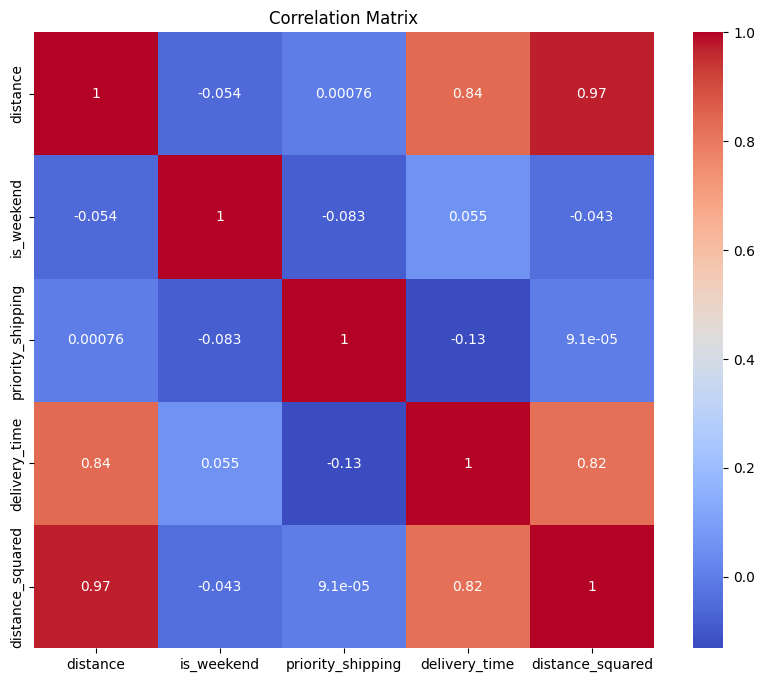

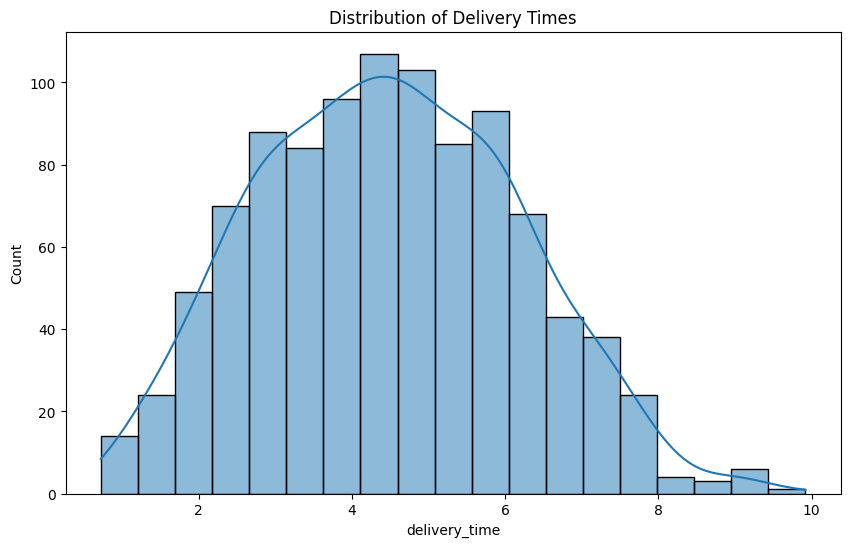

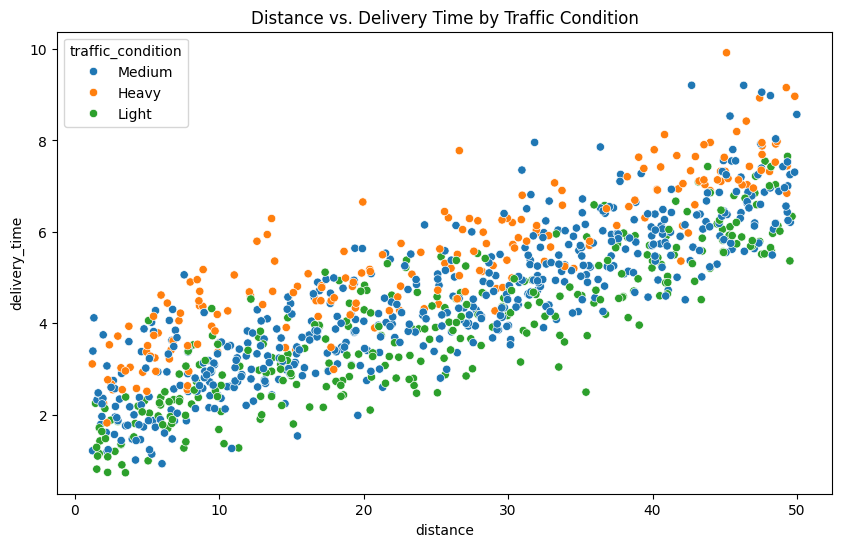

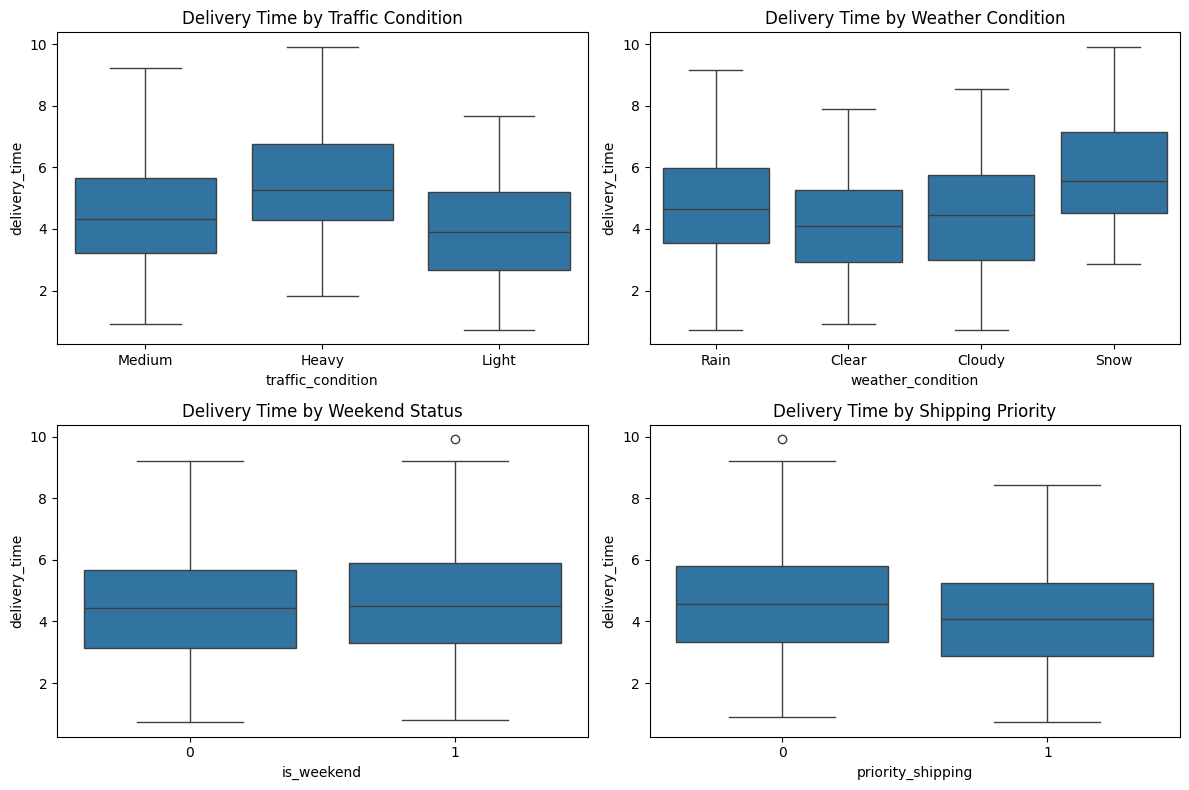

In [5]:
# Uncomment to run EDA
explore_data(data)

# Split data
X = data.drop('delivery_time', axis=1)
y = data['delivery_time']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing for numeric and categorical features
numeric_features = ['distance', 'order_hour', 'distance_squared']
categorical_features = ['traffic_condition', 'weather_condition']
binary_features = ['is_weekend', 'priority_shipping', 'rush_hour']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        # Binary features don't need transformation
    ],
    remainder='passthrough'
)

# Define and train multiple models


In [6]:
# Define and train multiple models
def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }
    
    results = {}
    
    for name, model in models.items():
        # Create pipeline with preprocessing and model
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        
        # Train model
        pipeline.fit(X_train, y_train)
        
        # Make predictions
        y_pred = pipeline.predict(X_test)
        
        # Evaluate
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        results[name] = {
            'pipeline': pipeline,
            'mae': mae,
            'rmse': rmse,
            'r2': r2,
            'predictions': y_pred
        }
        
        print(f"{name}:")
        print(f"  MAE: {mae:.2f} hours")
        print(f"  RMSE: {rmse:.2f} hours")
        print(f"  R²: {r2:.2f}")
        print()
    
    return results

model_results = train_and_evaluate_models(X_train, X_test, y_train, y_test)

# Select best model and save it
best_model_name = max(model_results.keys(), key=lambda x: model_results[x]['r2'])
best_pipeline = model_results[best_model_name]['pipeline']

print(f"Best model: {best_model_name}")

# Save the model
with open('delivery_time_model.pkl', 'wb') as file:
    pickle.dump(best_pipeline, file)

Linear Regression:
  MAE: 0.44 hours
  RMSE: 0.56 hours
  R²: 0.89

Random Forest:
  MAE: 0.49 hours
  RMSE: 0.62 hours
  R²: 0.87

Gradient Boosting:
  MAE: 0.45 hours
  RMSE: 0.57 hours
  R²: 0.89

Best model: Linear Regression


In [12]:
# Streamlit Application
def run_streamlit_app():
    st.title('Amazon Delivery Time Predictor')
    st.write('Enter package and delivery details to predict the estimated delivery time')
    
    col1, col2 = st.columns(2)
    
    with col1:
        distance = st.slider('Distance (miles)', 1.0, 50.0, 10.0)
        order_hour = st.slider('Order Hour (24-hour format)', 0, 23, 12)
        traffic = st.selectbox('Traffic Condition', ['Light', 'Medium', 'Heavy'])
    
    with col2:
        weather = st.selectbox('Weather Condition', ['Clear', 'Cloudy', 'Rain', 'Snow'])
        weekend = st.checkbox('Is Weekend')
        priority = st.checkbox('Priority Shipping')
    
    # Prepare input for prediction
    distance_squared = distance ** 2
    rush_hour = (7 <= order_hour <= 9) or (16 <= order_hour <= 18)
    
    input_data = pd.DataFrame({
        'distance': [distance],
        'order_hour': [order_hour],
        'traffic_condition': [traffic],
        'weather_condition': [weather],
        'is_weekend': [int(weekend)],
        'priority_shipping': [int(priority)],
        'distance_squared': [distance_squared],
        'rush_hour': [rush_hour]
    })
    
    if st.button('Predict Delivery Time'):
        # Load the trained model
        with open('delivery_time_model.pkl', 'rb') as file:
            model = pickle.load(file)
        
        # Add progress bar
        progress_bar = st.progress(0)
        status_text = st.empty()
        
        # Simulate prediction process
        for i in range(100):
            progress_bar.progress(i + 1)
            status_text.text(f"Calculating ETA: {i+1}%")
            time.sleep(0.01)
        
        # Make prediction
        prediction = model.predict(input_data)[0]
        
        # Convert to hours and minutes
        hours = int(prediction)
        minutes = int((prediction - hours) * 60)
        
        st.success(f"Estimated Delivery Time: {hours} hours and {minutes} minutes")
        
        # Show factors affecting delivery
        st.subheader("Factors affecting delivery time:")
        
        col1, col2 = st.columns(2)
        
        with col1:
            st.write(f"🚚 Distance: {distance} miles")
            st.write(f"🚦 Traffic: {traffic}")
            st.write(f"☁️ Weather: {weather}")
        
        with col2:
            st.write(f"🕒 Order Time: {order_hour}:00")
            st.write(f"📅 {'Weekend' if weekend else 'Weekday'}")
            st.write(f"⭐ {'Priority' if priority else 'Standard'} Shipping")
        
        # Visualization of factors
        st.subheader("Impact of Different Factors:")
        
        # Create comparison data
        comparison_data = []
        
        # Vary traffic
        for t in ['Light', 'Medium', 'Heavy']:
            temp_data = input_data.copy()
            temp_data['traffic_condition'] = t
            pred = model.predict(temp_data)[0]
            comparison_data.append(('Traffic: ' + t, pred))
        
        # Vary weather
        for w in ['Clear', 'Cloudy', 'Rain', 'Snow']:
            temp_data = input_data.copy()
            temp_data['weather_condition'] = w
            pred = model.predict(temp_data)[0]
            comparison_data.append(('Weather: ' + w, pred))
        
        # Convert to DataFrame for plotting
        comp_df = pd.DataFrame(comparison_data, columns=['Factor', 'Predicted Time'])
        
        # Plot
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(x='Predicted Time', y='Factor', data=comp_df, orient='h')
        plt.title('Impact of Different Factors on Delivery Time')
        plt.xlabel('Predicted Delivery Time (hours)')
        st.pyplot(fig)

# Uncomment to run Streamlit app
#For testing in a script environment:
if __name__ == '__main__':
     run_streamlit_app()


2025-05-02 11:52:07.875 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-02 11:52:08.858 
  command:

    streamlit run C:\Users\SWATHI PRIYA\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-05-02 11:52:08.859 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-02 11:52:08.860 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-02 11:52:08.861 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-02 11:52:08.862 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-02 11:52:08.863 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-02